In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
class GeometricTransformer:

    def __init__(self, image_path):
        self.image_path = image_path
        self.img_pil = Image.open(image_path)
        self.img_cv = cv2.imread(image_path)

    def translate(self, tx, ty):

        width, height = self.img_pil.size

        new_img = Image.new("RGB",(width+abs(int(tx))*2,height+abs(int(ty))*2),(255,255,255))
        new_img.paste(self.img_pil,(abs(int(tx)),abs(int(ty))))

        return new_img.crop((int(tx),int(ty),int(tx)+width,int(ty)+height))


    def rotate(self, angle):

        return self.img_pil.rotate(angle, expand=True)


    def scale(self, sx, sy):

        w,h = self.img_pil.size
        return self.img_pil.resize((int(w*sx),int(h*sy)),Image.LANCZOS)


    def shear(self, shx, shy):

        img_array = np.array(self.img_pil)

        h,w = img_array.shape[:2]

        x = np.arange(w)
        y = np.arange(h)

        X,Y = np.meshgrid(x,y)

        map_x = np.clip(X + shx*Y,0,w-1).astype(np.int32)
        map_y = np.clip(Y + shy*X,0,h-1).astype(np.int32)

        sheared = img_array[map_y,map_x]

        return Image.fromarray(sheared)


    def get_transformation(self,choice):

        if choice==1:

            tx=float(input("Translate X: "))
            ty=float(input("Translate Y: "))

            return "Translation",self.translate(tx,ty)

        elif choice==2:

            angle=float(input("Rotation Angle: "))
            return "Rotation",self.rotate(angle)

        elif choice==3:

            sx=float(input("Scale X: "))
            sy=float(input("Scale Y: "))

            return "Scaling",self.scale(sx,sy)

        elif choice==4:

            shx=float(input("Shear X: "))
            shy=float(input("Shear Y: "))

            return "Shearing",self.shear(shx,shy)

        else:
            return "Invalid",self.img_pil


    def interactive_menu(self):

        while True:

            print("\n===== GEOMETRIC MENU =====")
            print("1 Translation")
            print("2 Rotation")
            print("3 Scaling")
            print("4 Shearing")
            print("0 Exit")

            choice=int(input("Enter choice: "))

            if choice==0:
                break

            name,img=self.get_transformation(choice)

            plt.figure(figsize=(6,6))
            plt.imshow(img)
            plt.title(name)
            plt.axis("off")
            plt.show()



In [3]:
# FILTER CLASS
# =============================

class ImageFilters:

    def __init__(self,image_path):

        self.image_path=image_path
        self.img=cv2.imread(image_path)


    def point_filter(self):

        kernel=np.ones((3,3),np.float32)/9

        img=cv2.filter2D(self.img,-1,kernel)

        img=cv2.convertScaleAbs(img,alpha=5,beta=0)

        return img


    def mean_filter(self):

        return cv2.blur(self.img,(5,5))


    def median_filter(self):

        return cv2.medianBlur(self.img,5)


    def filter_menu(self):

        while True:

            print("\n===== FILTER MENU =====")
            print("1 Point Filter (1/9 Downscale + 5 Upscale)")
            print("2 Mean Filter")
            print("3 Median Filter")
            print("0 Exit")

            choice=int(input("Enter choice: "))

            if choice==0:
                break

            elif choice==1:

                result=self.point_filter()

            elif choice==2:

                result=self.mean_filter()

            elif choice==3:

                result=self.median_filter()

            else:

                print("Invalid choice")
                continue


            plt.figure(figsize=(6,6))
            plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title("Filter Result")
            plt.show()
            break


In [4]:
class FlexibleAffine:

    def __init__(self,image_path):

        self.image_path=image_path
        self.img=None
        self.rows=None
        self.cols=None
        self.matrix=np.eye(3)


    def read_image(self):

        self.img=cv2.imread(self.image_path,0)
        self.rows,self.cols=self.img.shape


    def add_rotation(self,angle):

        center=(self.cols//2,self.rows//2)

        rot=cv2.getRotationMatrix2D(center,angle,1)

        rot=np.vstack([rot,[0,0,1]])

        self.matrix=rot@self.matrix


    def add_scaling(self,sx,sy):

        scale=np.array([[sx,0,0],
                        [0,sy,0],
                        [0,0,1]])

        self.matrix=scale@self.matrix


    def add_shearing(self,shx,shy):

        shear=np.array([[1,shx,0],
                        [shy,1,0],
                        [0,0,1]])

        self.matrix=shear@self.matrix


    def add_translation(self,tx,ty):

        trans=np.array([[1,0,tx],
                        [0,1,ty],
                        [0,0,1]])

        self.matrix=trans@self.matrix


    def apply(self):

        final=self.matrix[:2,:]

        return cv2.warpAffine(self.img,final,(self.cols,self.rows))


    def display(self,result):

        plt.figure(figsize=(6,6))
        plt.imshow(result,cmap='gray')
        plt.axis("off")
        plt.show()


    def user_menu(self):

        while True:

            print("\n===== AFFINE MENU =====")
            print("1 Rotation")
            print("2 Scaling")
            print("3 Shearing")
            print("4 Translation")
            print("5 Apply")
            print("6 Exit")

            ch=input("Enter choices (example 1,3): ")

            if "1" in ch:

                angle=float(input("Angle: "))
                self.add_rotation(angle)

            if "2" in ch:

                sx=float(input("Scale X: "))
                sy=float(input("Scale Y: "))
                self.add_scaling(sx,sy)

            if "3" in ch:

                shx=float(input("Shear X: "))
                shy=float(input("Shear Y: "))
                self.add_shearing(shx,shy)

            if "4" in ch:

                tx=float(input("Translate X: "))
                ty=float(input("Translate Y: "))
                self.add_translation(tx,ty)

            if "5" in ch:

                result=self.apply()
                self.display(result)

            if "6" in ch:
                break



In [5]:
from google.colab import files

uploaded=files.upload()

for filename in uploaded.keys():

    full_path=os.path.abspath(filename)


Saving spider man.jpg to spider man.jpg



Choose Operation:
1 Affine
2 Geometric
3 Filters
0 Exit
3

===== FILTER MENU =====
1 Point Filter (1/9 Downscale + 5 Upscale)
2 Mean Filter
3 Median Filter
0 Exit
Enter choice: 1


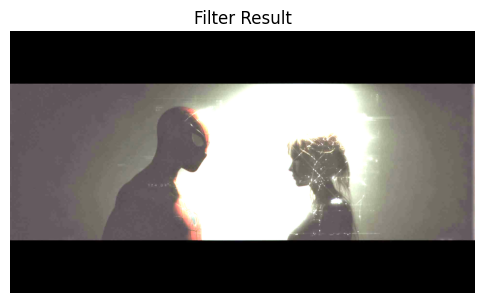


Press Enter to return to Main Menu...0

Choose Operation:
1 Affine
2 Geometric
3 Filters
0 Exit
0
Program Closed.


In [10]:
while True:

    choice = int(input("\nChoose Operation:\n1 Affine\n2 Geometric\n3 Filters\n0 Exit\n"))

    if choice == 1:

        obj = FlexibleAffine(full_path)
        obj.read_image()
        obj.user_menu()

        input("\nPress Enter to return to Main Menu...")

    elif choice == 2:

        obj = GeometricTransformer(full_path)
        obj.interactive_menu()

        input("\nPress Enter to return to Main Menu...")

    elif choice == 3:

        obj = ImageFilters(full_path)
        obj.filter_menu()

        input("\nPress Enter to return to Main Menu...")

    elif choice == 0:

        print("Program Closed.")
        break

    else:
        print("Invalid Choice")